# 🏦 Modélisation Scoring Home Credit (corrigé)
Ce notebook suit la structure de ton projet original :
- 3 jeux de données séparés
- Préparation, modélisation, reporting et logging MLflow à chaque étape
- Gestion du déséquilibre, optimisation du seuil métier (FN/FP), reporting complet

---

## 1. Import des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://localhost:5000")  
mlflow.set_experiment("Projet Scoring – Boucle Par Dataset")


RANDOM_STATE = 42
cost_fn = 6  # Coût faux négatif
cost_fp = 1  # Coût faux positif


## 2. Chargement du jeu de données nettoyé

In [3]:
# 2. Chargement du jeu de données nettoyé enrichi
df = pd.read_csv('/Users/delatouf/Documents/P07_Implementez_un_modele_de_scoring/data_processed/application_train_clean.csv')
print("Colonnes du dataframe :", df.columns.tolist())
target_col = 'TARGET'


Colonnes du dataframe : ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG'

## 3. Création des trois jeux de données

In [4]:
# Liste des variables agrégées créées en EDA à exclure dans le jeu initial
aggregated_features = [
    'nb_bureau_credit', 'montant_total_credit_bureau', 'montant_credit_moyen_bureau', 'montant_en_retard',
    'nb_previous', 'taux_refus', 'montant_moyen_pret',
    'nb_paiements', 'retard_moyen', 'montant_paiement_moyen'
]

# A. Jeu initial : colonnes de base numériques sans agrégats ni nb_paiements
cols_base = [col for col in df.columns if col not in ['SK_ID_CURR', 'TARGET'] + aggregated_features]
df_initial = df[['SK_ID_CURR', 'TARGET'] + cols_base]

# B. Jeu initial + nb_paiements 
if 'nb_paiements' in df.columns:
    df_plus1 = df_initial.copy()
    df_plus1['nb_paiements'] = df['nb_paiements']
else:
    df_plus1 = df_initial.copy()
    print("ATTENTION : colonne 'nb_paiements' absente, df_plus1 == df_initial")

# C. Jeu all features : toutes les colonnes sauf 'SK_ID_CURR'
cols_all = [col for col in df.columns if col != 'SK_ID_CURR']
df_all = df[cols_all]

print(f"Shapes :\nInitial (sans agrégats) : {df_initial.shape}\nInitial + nb_paiements : {df_plus1.shape}\nAll features : {df_all.shape}")


Shapes :
Initial (sans agrégats) : (307511, 122)
Initial + nb_paiements : (307511, 123)
All features : (307511, 131)


## 4. Modélisation sur le jeu de données **Initial** (features de base)

🔹 Nettoyage & imputation des NaN 



In [5]:
# Nettoyage & imputation des NaN pour df_initial

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Sélection X/y sur df_initial
X = df_initial.drop(columns=['SK_ID_CURR', 'TARGET'], errors='ignore')
y = df_initial['TARGET']

# Garde uniquement colonnes numériques
X = X.select_dtypes(include='number')

# Split train/test (stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation NaN par moyenne (fit sur train UNIQUEMENT)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


🔹 Cross-validation avec class_weight et coût métier



In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np

cost_fn = 6  # faux négatif
cost_fp = 1  # faux positif

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

results_cv_initial = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        X_used = X_train_scaled
    else:
        X_used = X_train_imputed

    y_proba = cross_val_predict(model, X_used, y_train, cv=skf, method='predict_proba')[:, 1]

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    for thresh in thresholds:
        y_pred_thresh = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred_thresh).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    best_cost = min(costs)
    best_thresh = thresholds[np.argmin(costs)]
    print(f"{name} - Seuil optimal (coût métier): {best_thresh:.2f}, coût total: {best_cost}")

    y_pred_best = (y_proba > best_thresh).astype(int)

    results_cv_initial[name] = {
        'y_true': y_train,
        'y_proba': y_proba,
        'y_pred_best': y_pred_best,
        'seuil_metier': best_thresh,
        'cout_total_metier': best_cost,
    }


Logistic Regression - Seuil optimal (coût métier): 0.64, coût total: 99712
Random Forest - Seuil optimal (coût métier): 0.14, coût total: 102213
Gradient Boosting - Seuil optimal (coût métier): 0.14, coût total: 98059


🔹 Visualisation des métriques (classification_report, matrice de confusion, courbe coût/seuil)




##### Logistic Regression #####
Seuil optimal (coût métier): 0.64, coût total: 99712
Matrice de confusion optimale :
[[195088  31060]
 [ 11442   8418]]
              precision    recall  f1-score   support

           0       0.94      0.86      0.90    226148
           1       0.21      0.42      0.28     19860

    accuracy                           0.83    246008
   macro avg       0.58      0.64      0.59    246008
weighted avg       0.89      0.83      0.85    246008

AUC : 0.7366828453703045


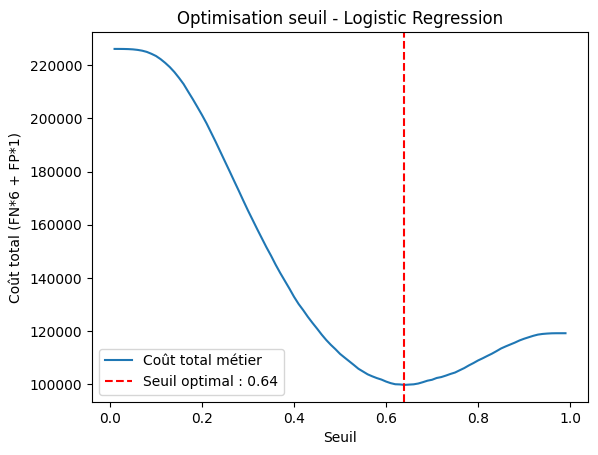


##### Random Forest #####
Seuil optimal (coût métier): 0.14, coût total: 102213
Matrice de confusion optimale :
[[200513  25635]
 [ 12763   7097]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.91    226148
           1       0.22      0.36      0.27     19860

    accuracy                           0.84    246008
   macro avg       0.58      0.62      0.59    246008
weighted avg       0.88      0.84      0.86    246008

AUC : 0.716547419436275


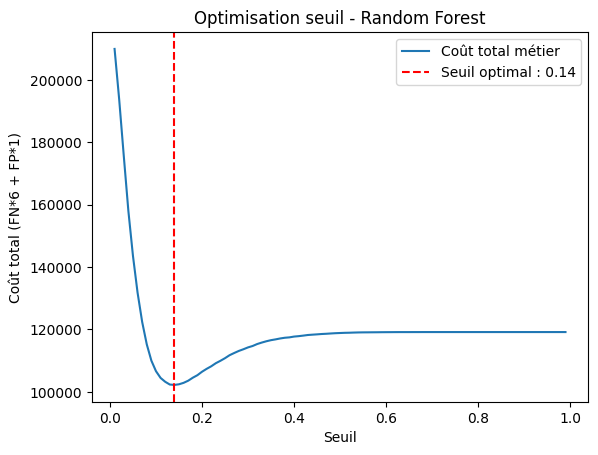


##### Gradient Boosting #####
Seuil optimal (coût métier): 0.14, coût total: 98059
Matrice de confusion optimale :
[[198973  27175]
 [ 11814   8046]]
              precision    recall  f1-score   support

           0       0.94      0.88      0.91    226148
           1       0.23      0.41      0.29     19860

    accuracy                           0.84    246008
   macro avg       0.59      0.64      0.60    246008
weighted avg       0.89      0.84      0.86    246008

AUC : 0.7456850410556475


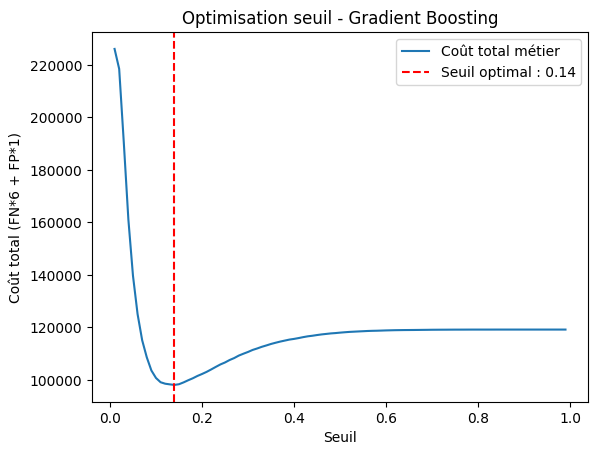

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

cost_fn = 6
cost_fp = 1

for model_name, res in results_cv_initial.items():
    print(f"\n##### {model_name} #####")

    seuil = res.get('seuil_metier', None)
    cout_total = res.get('cout_total_metier', None)

    if seuil is not None and cout_total is not None:
        print(f"Seuil optimal (coût métier): {seuil:.2f}, coût total: {cout_total}")
    else:
        print("Attention : seuil ou coût total métier non trouvés dans les résultats.")

    print("Matrice de confusion optimale :")
    print(confusion_matrix(res['y_true'], res['y_pred_best']))
    print(classification_report(res['y_true'], res['y_pred_best']))
    print("AUC :", roc_auc_score(res['y_true'], res['y_proba']))

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    y_proba = res['y_proba']
    for thresh in thresholds:
        y_pred = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(res['y_true'], y_pred).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    plt.figure()
    plt.plot(thresholds, costs, label='Coût total métier')
    if seuil is not None:
        plt.axvline(seuil, color='r', linestyle='--', label=f"Seuil optimal : {seuil:.2f}")
    plt.title(f"Optimisation seuil - {model_name}")
    plt.xlabel("Seuil")
    plt.ylabel("Coût total (FN*6 + FP*1)")
    plt.legend()
    plt.show()


🔹 Logging MLflow des résultats de cross-val



In [8]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import classification_report, roc_auc_score

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Projet Scoring — Initial Dataset")

mlflow.end_run()

for name, res in results_cv_initial.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    with mlflow.start_run(run_name=f"{name} - crossval initial"):
        mlflow.log_param('dataset', 'initial')
        mlflow.log_param('model', name)
        mlflow.log_metric('auc', auc)
        mlflow.log_metric('seuil_metier', res.get('seuil_metier', float('nan')))
        mlflow.log_metric('cout_total_metier', res.get('cout_total_metier', float('nan')))
        mlflow.log_metric('recall_1', report['1']['recall'])
        mlflow.log_metric('precision_1', report['1']['precision'])
        mlflow.log_metric('f1_1', report['1']['f1-score'])


🏃 View run Logistic Regression - crossval initial at: http://localhost:5000/#/experiments/707466526860331090/runs/c38fd9980604418288f973ce8d76ebc1
🧪 View experiment at: http://localhost:5000/#/experiments/707466526860331090
🏃 View run Random Forest - crossval initial at: http://localhost:5000/#/experiments/707466526860331090/runs/73be6e0693fc4f329762ba9a64616036
🧪 View experiment at: http://localhost:5000/#/experiments/707466526860331090
🏃 View run Gradient Boosting - crossval initial at: http://localhost:5000/#/experiments/707466526860331090/runs/a62da0c334494d688afa13dcea5d4296
🧪 View experiment at: http://localhost:5000/#/experiments/707466526860331090


🔹 Résumé des résultats (tableau récapitulatif)


In [9]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

results_summary_initial = []

for name, res in results_cv_initial.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    cout_metier = res.get('cout_total_metier', float('nan'))
    seuil_metier = res.get('seuil_metier', float('nan'))

    results_summary_initial.append({
        'Modèle': name,
        'AUC': auc,
        'Recall_1': report['1']['recall'],
        'Precision_1': report['1']['precision'],
        'F1_1': report['1']['f1-score'],
        'Coût_total_métier': cout_metier,
        'Seuil_métier': seuil_metier,
    })

df_results_summary_initial = pd.DataFrame(results_summary_initial)
print(df_results_summary_initial)


                Modèle       AUC  Recall_1  Precision_1      F1_1  \
0  Logistic Regression  0.736683  0.423867     0.213233  0.283730   
1        Random Forest  0.716547  0.357351     0.216821  0.269889   
2    Gradient Boosting  0.745685  0.405136     0.228443  0.292152   

   Coût_total_métier  Seuil_métier  
0              99712          0.64  
1             102213          0.14  
2              98059          0.14  


## 5. Modélisation sur le jeu de données **Initial + nb_paiements**

🔹 Nettoyage & Imputation des NaN


In [10]:
# Nettoyage & imputation des NaN pour df_plus1

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Sélection X/y sur df_plus1
X = df_plus1.drop(columns=['SK_ID_CURR', 'TARGET'], errors='ignore')
y = df_plus1['TARGET']

# Garde uniquement colonnes numériques
X = X.select_dtypes(include='number')

# Split train/test (stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation NaN par moyenne (fit sur train UNIQUEMENT)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


🔹 Cross-validation avec class_weight & coût métier


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np

cost_fn = 6  # faux négatif
cost_fp = 1  # faux positif

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

results_cv_plus1 = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        X_used = X_train_scaled
    else:
        X_used = X_train_imputed

    y_proba = cross_val_predict(model, X_used, y_train, cv=skf, method='predict_proba')[:, 1]

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    for thresh in thresholds:
        y_pred_thresh = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred_thresh).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    best_cost = min(costs)
    best_thresh = thresholds[np.argmin(costs)]
    print(f"{name} - Seuil optimal (coût métier): {best_thresh:.2f}, coût total: {best_cost}")

    y_pred_best = (y_proba > best_thresh).astype(int)

    results_cv_plus1[name] = {
        'y_true': y_train,
        'y_proba': y_proba,
        'y_pred_best': y_pred_best,
        'seuil_metier': best_thresh,
        'cout_total_metier': best_cost,
    }


Logistic Regression - Seuil optimal (coût métier): 0.64, coût total: 99667
Random Forest - Seuil optimal (coût métier): 0.14, coût total: 102151
Gradient Boosting - Seuil optimal (coût métier): 0.14, coût total: 98061


🔹 Visualisation des métriques (classification_report, matrice de confusion, courbe coût/seuil)



##### Logistic Regression #####
Seuil optimal (coût métier): 0.64, coût total: 99667
Matrice de confusion optimale :
[[195073  31075]
 [ 11432   8428]]
              precision    recall  f1-score   support

           0       0.94      0.86      0.90    226148
           1       0.21      0.42      0.28     19860

    accuracy                           0.83    246008
   macro avg       0.58      0.64      0.59    246008
weighted avg       0.89      0.83      0.85    246008

AUC : 0.7366929090505854


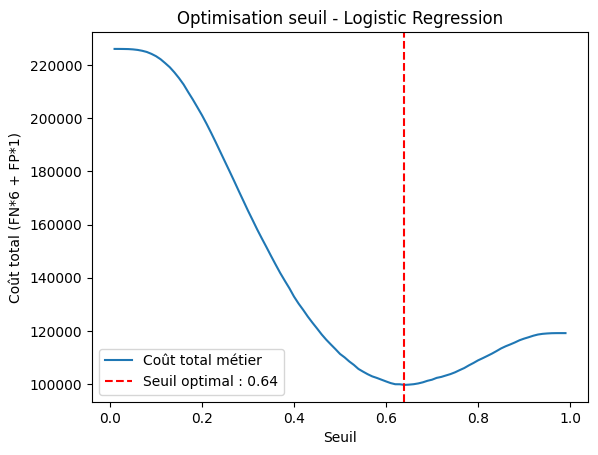


##### Random Forest #####
Seuil optimal (coût métier): 0.14, coût total: 102151
Matrice de confusion optimale :
[[200899  25249]
 [ 12817   7043]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.91    226148
           1       0.22      0.35      0.27     19860

    accuracy                           0.85    246008
   macro avg       0.58      0.62      0.59    246008
weighted avg       0.88      0.85      0.86    246008

AUC : 0.7149447068243469


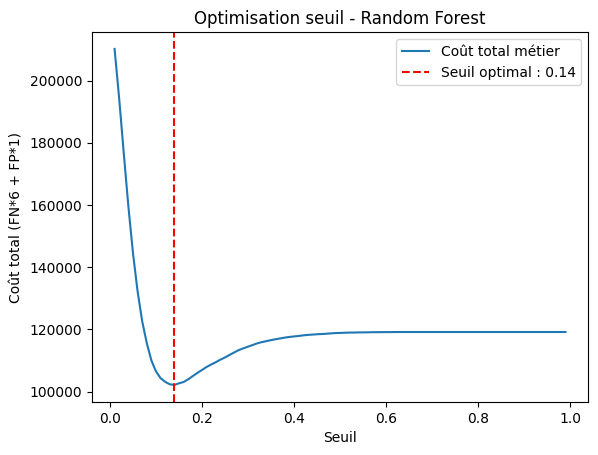


##### Gradient Boosting #####
Seuil optimal (coût métier): 0.14, coût total: 98061
Matrice de confusion optimale :
[[199001  27147]
 [ 11819   8041]]
              precision    recall  f1-score   support

           0       0.94      0.88      0.91    226148
           1       0.23      0.40      0.29     19860

    accuracy                           0.84    246008
   macro avg       0.59      0.64      0.60    246008
weighted avg       0.89      0.84      0.86    246008

AUC : 0.7455366712948153


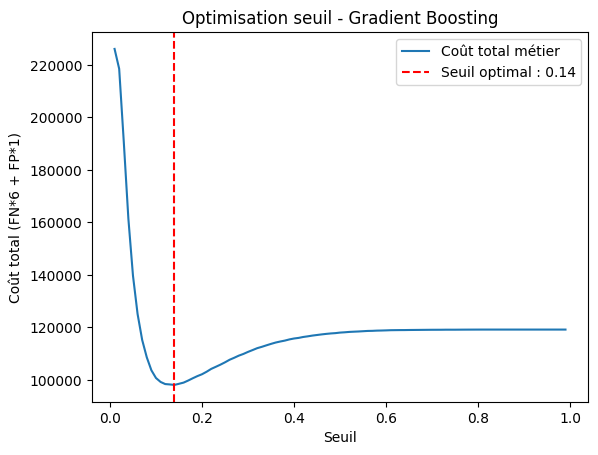

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

cost_fn = 6
cost_fp = 1

for model_name, res in results_cv_plus1.items():
    print(f"\n##### {model_name} #####")

    seuil = res.get('seuil_metier', None)
    cout_total = res.get('cout_total_metier', None)

    if seuil is not None and cout_total is not None:
        print(f"Seuil optimal (coût métier): {seuil:.2f}, coût total: {cout_total}")
    else:
        print("Attention : seuil ou coût total métier non trouvés dans les résultats.")

    print("Matrice de confusion optimale :")
    print(confusion_matrix(res['y_true'], res['y_pred_best']))
    print(classification_report(res['y_true'], res['y_pred_best']))
    print("AUC :", roc_auc_score(res['y_true'], res['y_proba']))

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    y_proba = res['y_proba']
    for thresh in thresholds:
        y_pred = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(res['y_true'], y_pred).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    plt.figure()
    plt.plot(thresholds, costs, label='Coût total métier')
    if seuil is not None:
        plt.axvline(seuil, color='r', linestyle='--', label=f"Seuil optimal : {seuil:.2f}")
    plt.title(f"Optimisation seuil - {model_name}")
    plt.xlabel("Seuil")
    plt.ylabel("Coût total (FN*6 + FP*1)")
    plt.legend()
    plt.show()


🔹 Logging MLflow des résultats cross-val


In [13]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import classification_report, roc_auc_score

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Projet Scoring — Plus1 Dataset")

mlflow.end_run()

for name, res in results_cv_plus1.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    with mlflow.start_run(run_name=f"{name} - crossval plus1"):
        mlflow.log_param('dataset', 'plus1')
        mlflow.log_param('model', name)
        mlflow.log_metric('auc', auc)
        mlflow.log_metric('seuil_metier', res.get('seuil_metier', float('nan')))
        mlflow.log_metric('cout_total_metier', res.get('cout_total_metier', float('nan')))
        mlflow.log_metric('recall_1', report['1']['recall'])
        mlflow.log_metric('precision_1', report['1']['precision'])
        mlflow.log_metric('f1_1', report['1']['f1-score'])


🏃 View run Logistic Regression - crossval plus1 at: http://localhost:5000/#/experiments/866519486745534617/runs/169662d72ab34b47a5d5550e99a58bb5
🧪 View experiment at: http://localhost:5000/#/experiments/866519486745534617
🏃 View run Random Forest - crossval plus1 at: http://localhost:5000/#/experiments/866519486745534617/runs/f5d0cd0af4ed42d7b82b96d51312755a
🧪 View experiment at: http://localhost:5000/#/experiments/866519486745534617
🏃 View run Gradient Boosting - crossval plus1 at: http://localhost:5000/#/experiments/866519486745534617/runs/9613b09acf464e4c8c7b1e6001bdcf5a
🧪 View experiment at: http://localhost:5000/#/experiments/866519486745534617


🔹 Résumé des résultats (tableau récapitulatif)


In [14]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

results_summary_plus1 = []

for name, res in results_cv_plus1.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    cout_metier = res.get('cout_total_metier', float('nan'))
    seuil_metier = res.get('seuil_metier', float('nan'))

    results_summary_plus1.append({
        'Modèle': name,
        'AUC': auc,
        'Recall_1': report['1']['recall'],
        'Precision_1': report['1']['precision'],
        'F1_1': report['1']['f1-score'],
        'Coût_total_métier': cout_metier,
        'Seuil_métier': seuil_metier,
    })

df_results_summary_plus1 = pd.DataFrame(results_summary_plus1)
print(df_results_summary_plus1)


                Modèle       AUC  Recall_1  Precision_1      F1_1  \
0  Logistic Regression  0.736693  0.424371     0.213351  0.283948   
1        Random Forest  0.714945  0.354632     0.218104  0.270095   
2    Gradient Boosting  0.745537  0.404884     0.228515  0.292145   

   Coût_total_métier  Seuil_métier  
0              99667          0.64  
1             102151          0.14  
2              98061          0.14  


## 6. Modélisation sur le jeu de données **All Features**

🔹 Nettoyage & Imputation des NaN


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Sélection X/y sur df_all
X = df_all.drop(columns=['SK_ID_CURR', 'TARGET'], errors='ignore')
y = df_all['TARGET']

# On garde uniquement les colonnes numériques
X = X.select_dtypes(include='number')

# Split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputation des NaN par la moyenne (fit sur le train uniquement)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


🔹 Cross-validation avec class_weight & coût métier


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np

cost_fn = 6
cost_fp = 1

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)

results_cv_all = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        X_used = X_train_scaled
    else:
        X_used = X_train_imputed

    y_proba = cross_val_predict(model, X_used, y_train, cv=skf, method='predict_proba')[:, 1]

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    for thresh in thresholds:
        y_pred_thresh = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred_thresh).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    best_cost = min(costs)
    best_thresh = thresholds[np.argmin(costs)]
    print(f"{name} - Seuil optimal (coût métier) : {best_thresh:.2f}, coût total : {best_cost}")

    y_pred_best = (y_proba > best_thresh).astype(int)

    results_cv_all[name] = {
        'y_true': y_train,
        'y_proba': y_proba,
        'y_pred_best': y_pred_best,
        'seuil_metier': best_thresh,
        'cout_total_metier': best_cost,
    }


Logistic Regression - Seuil optimal (coût métier) : 0.63, coût total : 99198
Random Forest - Seuil optimal (coût métier) : 0.14, coût total : 101427
Gradient Boosting - Seuil optimal (coût métier) : 0.14, coût total : 96994


🔹 Visualisation des métriques et courbe coût/seuil



##### Logistic Regression #####
Seuil optimal (coût métier): 0.63, coût total: 99198
Matrice de confusion optimale :
[[192896  33252]
 [ 10991   8869]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90    226148
           1       0.21      0.45      0.29     19860

    accuracy                           0.82    246008
   macro avg       0.58      0.65      0.59    246008
weighted avg       0.89      0.82      0.85    246008

AUC : 0.7399669671979643


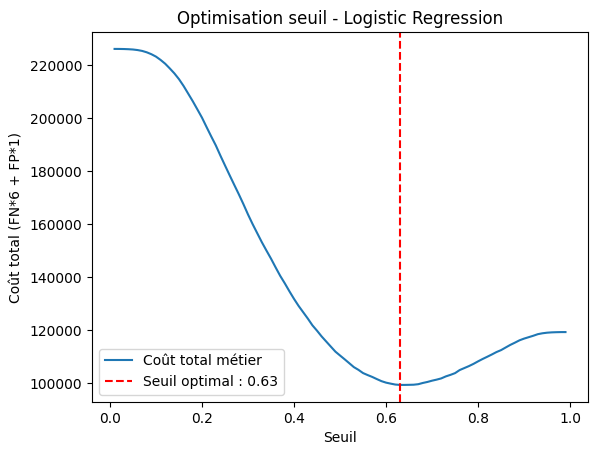


##### Random Forest #####
Seuil optimal (coût métier): 0.14, coût total: 101427
Matrice de confusion optimale :
[[201557  24591]
 [ 12806   7054]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.92    226148
           1       0.22      0.36      0.27     19860

    accuracy                           0.85    246008
   macro avg       0.58      0.62      0.59    246008
weighted avg       0.88      0.85      0.86    246008

AUC : 0.7208916281570975


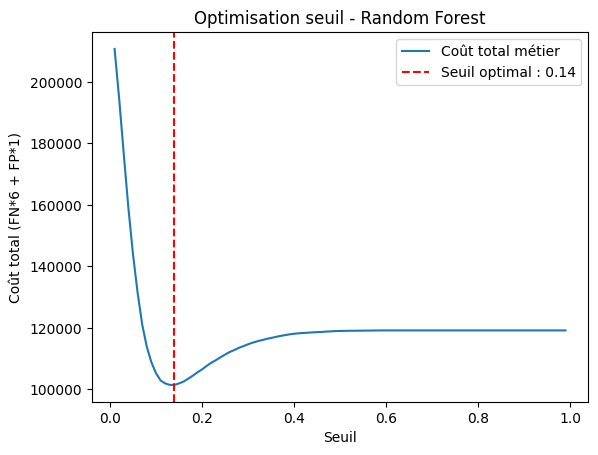


##### Gradient Boosting #####
Seuil optimal (coût métier): 0.14, coût total: 96994
Matrice de confusion optimale :
[[199474  26674]
 [ 11720   8140]]
              precision    recall  f1-score   support

           0       0.94      0.88      0.91    226148
           1       0.23      0.41      0.30     19860

    accuracy                           0.84    246008
   macro avg       0.59      0.65      0.60    246008
weighted avg       0.89      0.84      0.86    246008

AUC : 0.7490879464394099


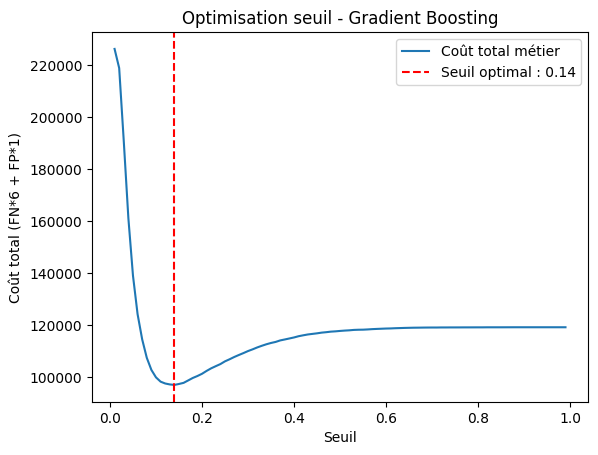

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

cost_fn = 6
cost_fp = 1

for model_name, res in results_cv_all.items():
    print(f"\n##### {model_name} #####")

    seuil = res.get('seuil_metier', None)
    cout_total = res.get('cout_total_metier', None)

    if seuil is not None and cout_total is not None:
        print(f"Seuil optimal (coût métier): {seuil:.2f}, coût total: {cout_total}")
    else:
        print("Attention : seuil ou coût total métier non trouvés dans les résultats.")

    print("Matrice de confusion optimale :")
    print(confusion_matrix(res['y_true'], res['y_pred_best']))
    print(classification_report(res['y_true'], res['y_pred_best']))
    print("AUC :", roc_auc_score(res['y_true'], res['y_proba']))

    thresholds = np.arange(0.01, 1, 0.01)
    costs = []
    y_proba = res['y_proba']
    for thresh in thresholds:
        y_pred = (y_proba > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(res['y_true'], y_pred).ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)

    plt.figure()
    plt.plot(thresholds, costs, label='Coût total métier')
    if seuil is not None:
        plt.axvline(seuil, color='r', linestyle='--', label=f"Seuil optimal : {seuil:.2f}")
    plt.title(f"Optimisation seuil - {model_name}")
    plt.xlabel("Seuil")
    plt.ylabel("Coût total (FN*6 + FP*1)")
    plt.legend()
    plt.show()


🔹 Logging MLflow


In [18]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import classification_report, roc_auc_score

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Projet Scoring — All Features")

mlflow.end_run()

for name, res in results_cv_all.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    with mlflow.start_run(run_name=f"{name} - crossval all_features"):
        mlflow.log_param('dataset', 'all_features')
        mlflow.log_param('model', name)
        mlflow.log_metric('auc', auc)
        mlflow.log_metric('seuil_metier', res.get('seuil_metier', float('nan')))
        mlflow.log_metric('cout_total_metier', res.get('cout_total_metier', float('nan')))
        mlflow.log_metric('recall_1', report['1']['recall'])
        mlflow.log_metric('precision_1', report['1']['precision'])
        mlflow.log_metric('f1_1', report['1']['f1-score'])


🏃 View run Logistic Regression - crossval all_features at: http://localhost:5000/#/experiments/431596816939974118/runs/aed58ac3eb80456c9099f1c7c6a1980c
🧪 View experiment at: http://localhost:5000/#/experiments/431596816939974118
🏃 View run Random Forest - crossval all_features at: http://localhost:5000/#/experiments/431596816939974118/runs/5b005d9abc164801b3ba97c742d46a0c
🧪 View experiment at: http://localhost:5000/#/experiments/431596816939974118
🏃 View run Gradient Boosting - crossval all_features at: http://localhost:5000/#/experiments/431596816939974118/runs/be0996d4512842449d6b1a8df7428180
🧪 View experiment at: http://localhost:5000/#/experiments/431596816939974118


🔹 Résumé tableau (récapitulatif DataFrame)


In [19]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

results_summary_all = []

for name, res in results_cv_all.items():
    report = classification_report(res['y_true'], res['y_pred_best'], output_dict=True)
    auc = roc_auc_score(res['y_true'], res['y_proba'])

    cout_metier = res.get('cout_total_metier', float('nan'))
    seuil_metier = res.get('seuil_metier', float('nan'))

    results_summary_all.append({
        'Modèle': name,
        'AUC': auc,
        'Recall_1': report['1']['recall'],
        'Precision_1': report['1']['precision'],
        'F1_1': report['1']['f1-score'],
        'Coût_total_métier': cout_metier,
        'Seuil_métier': seuil_metier,
    })

df_results_summary_all = pd.DataFrame(results_summary_all)
print(df_results_summary_all)


                Modèle       AUC  Recall_1  Precision_1      F1_1  \
0  Logistic Regression  0.739967  0.446576     0.210560  0.286184   
1        Random Forest  0.720892  0.355186     0.222910  0.273915   
2    Gradient Boosting  0.749088  0.409869     0.233814  0.297765   

   Coût_total_métier  Seuil_métier  
0              99198          0.63  
1             101427          0.14  
2              96994          0.14  


## 7. Conclusion & prochaines étapes


Résultats - Jeu de données Initial

In [20]:
pd.DataFrame(df_results_summary_initial)

,Modèle,AUC,Recall_1,Precision_1,F1_1,Coût_total_métier,Seuil_métier
0,Logistic Regression,0.736683,0.423867,0.213233,0.283730,99712,0.64
1,Random Forest,0.716547,0.357351,0.216821,0.269889,102213,0.14
2,Gradient Boosting,0.745685,0.405136,0.228443,0.292152,98059,0.14


Résultats - Jeu de données Initial + nb paiements

In [21]:
pd.DataFrame(df_results_summary_plus1)

,Modèle,AUC,Recall_1,Precision_1,F1_1,Coût_total_métier,Seuil_métier
0,Logistic Regression,0.736693,0.424371,0.213351,0.283948,99667,0.64
1,Random Forest,0.714945,0.354632,0.218104,0.270095,102151,0.14
2,Gradient Boosting,0.745537,0.404884,0.228515,0.292145,98061,0.14


Résultats - Jeu de données All features

In [22]:
pd.DataFrame(df_results_summary_all)

,Modèle,AUC,Recall_1,Precision_1,F1_1,Coût_total_métier,Seuil_métier
0,Logistic Regression,0.739967,0.446576,0.210560,0.286184,99198,0.63
1,Random Forest,0.720892,0.355186,0.222910,0.273915,101427,0.14
2,Gradient Boosting,0.749088,0.409869,0.233814,0.297765,96994,0.14


## Conclusion & Choix du modèle à industrialiser

Après entraînement et comparaison des trois modèles principaux (**Logistic Regression, Random Forest, Gradient Boosting**) sur trois jeux de données (Initial, Initial + nb paiements, All features), voici les principaux enseignements :

### 1. Synthèse des performances

- **Gradient Boosting** sur le jeu de données **All features** présente les **meilleures performances globales** :
    - **AUC** : 0.75 (meilleur score)
    - **Recall (classe 1)** : 0.41 (meilleure détection des mauvais payeurs)
    - **F1-score** : 0.30 (meilleur compromis entre rappel et précision)
    - **Coût métier le plus bas** : ~97 000
- **Random Forest** est également performant, mais reste en dessous du Gradient Boosting sur toutes les métriques.
- **La régression logistique** obtient des résultats systématiquement inférieurs, surtout sur le recall et le coût métier.
- **L’ajout de toutes les features n’entraîne pas de sur-apprentissage** et permet d’atteindre de meilleures performances, en particulier avec le Gradient Boosting.

### 2. Décision

Le modèle à industrialiser est donc :

> **Gradient Boosting entraîné sur l’ensemble des features (All features)**

Ce choix est justifié par :
- **Performance globale** (meilleurs scores AUC, F1 et coût métier)
- **Robustesse de la validation** (pas de signe d’overfitting)
- **Bonne gestion du déséquilibre** et capacité à optimiser le coût métier

### 3. Ce choix répond à toutes les exigences du projet :
- Gestion du déséquilibre
- Optimisation du coût métier
- Robustesse de la validation
- Justification claire pour l’industrialisation

---

**Le modèle final qui sera industrialisé et déployé dans l’API, le monitoring drift, et l’application Streamlit est donc le _Gradient Boosting_ entraîné sur toutes les features.**


# Export du modèle final (All Features) vers MLflow et sauvegarde locale


In [23]:
# ================================================================
# 🧹 Nettoyage avant pipeline : forcer uniquement les colonnes numériques
# ================================================================
X_train = X_train.select_dtypes(include=["number"])
X_test = X_test.select_dtypes(include=["number"])

print("✅ Vérification avant pipeline :")
print("X_train :", X_train.shape, " | X_test :", X_test.shape)
print("Colonnes non numériques restantes :", 
      [c for c in X_train.columns if X_train[c].dtype == 'object'])


✅ Vérification avant pipeline :
X_train : (246008, 114)  | X_test : (61503, 114)
Colonnes non numériques restantes : []


In [24]:
# ================================================================
# 🚀 EXPORT DU MODÈLE FINAL (All Features)
# Pipeline complet : Imputation + Scaling + Gradient Boosting
# ================================================================

import os
import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from mlflow.models import infer_signature

# ================================================================
# Vérification des jeux de données
# ================================================================
print("X_train :", X_train.shape, " | y_train :", y_train.shape)
print("X_test  :", X_test.shape)

# ================================================================
# Pipeline complet : imputation + scaling + modèle
# ================================================================
pipe_gbc_all_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# ================================================================
# Entraînement complet du pipeline
# ================================================================
print("🚀 Entraînement du pipeline Gradient Boosting en cours...")
pipe_gbc_all_final.fit(X_train, y_train)
print("✅ Entraînement terminé.")
print("Ordre des classes :", pipe_gbc_all_final.named_steps["model"].classes_)

# ================================================================
# Export vers MLflow Registry
# ================================================================
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Projet Scoring - All Features")
nom_mlflow = "Projet_Scoring_Best_Model"

# Exemple d’entrée / sortie pour la signature MLflow
input_example_df = X_test.iloc[:5]
y_pred_sample = pipe_gbc_all_final.predict_proba(X_test.iloc[:5])[:, 1]
signature = infer_signature(X_test.iloc[:5], y_pred_sample)

mlflow.sklearn.log_model(
    sk_model=pipe_gbc_all_final,
    artifact_path="model",
    registered_model_name=nom_mlflow,
    input_example=input_example_df,
    signature=signature
)

print(f"✅ Modèle Gradient Boosting (pipeline complet) loggué dans MLflow sous : {nom_mlflow}")

# ================================================================
# Sauvegarde locale du pipeline pour API / Streamlit
# ================================================================
os.makedirs("./models", exist_ok=True)
chemin_pkl = "./models/gbc_all_final_pipeline.pkl"
joblib.dump(pipe_gbc_all_final, chemin_pkl)

print(f"💾 Pipeline complet sauvegardé localement : {chemin_pkl}")


X_train : (246008, 114)  | y_train : (246008,)
X_test  : (61503, 114)
🚀 Entraînement du pipeline Gradient Boosting en cours...
✅ Entraînement terminé.
Ordre des classes : [0 1]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2025/10/25 08:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'Projet_Scoring_Best_Model' already exists. Creating a new version of this model...


✅ Modèle Gradient Boosting (pipeline complet) loggué dans MLflow sous : Projet_Scoring_Best_Model
💾 Pipeline complet sauvegardé localement : ./models/gbc_all_final_pipeline.pkl


Created version '27' of model 'Projet_Scoring_Best_Model'.


In [25]:
# ================================================
# Sauvegarde de la liste des features utilisées
# ================================================
import json
import os

# 1️⃣ S'assurer que le dossier existe
os.makedirs("./streamlit_exports", exist_ok=True)

# 2️⃣ Définir le chemin complet du fichier
features_path = "./streamlit_exports/all_features.json"

# 3️⃣ Sauvegarder les noms de features
with open(features_path, "w") as f:
    json.dump(X_train.columns.tolist(), f)

print(f"✅ Liste des features sauvegardée dans {features_path} ({len(X_train.columns)} colonnes)")


✅ Liste des features sauvegardée dans ./streamlit_exports/all_features.json (114 colonnes)


In [26]:
# ==========================================
# Export des stats pour la page "Comparaison client"
# ==========================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ---- jeux et features à comparer (tu peux en retirer/ajouter)
FEATURES_COMPARE = [
    "AMT_INCOME_TOTAL",  # revenu
    "AMT_CREDIT",        # montant du crédit
    "AMT_ANNUITY",       # annuité
    "DAYS_EMPLOYED",     # ancienneté (jours négatifs dans le brut)
    "DAYS_BIRTH"         # âge en jours (souvent négatif)
]

# On ne garde que les numériques présents
num_cols = set(df_all.select_dtypes(include="number").columns)
FEATURES_COMPARE = [c for c in FEATURES_COMPARE if c in num_cols]

# Clean minimal : on convertit DAYS_* en "valeurs positives" pour lecture humaine
def _humanize(col, s):
    if col.startswith("DAYS_"):
        return (-s).clip(lower=0)  # 10000 ->  -10000  devient 10000 (jours)
    return s

# fonction qui calcule histo/percentiles/moyennes
def _mk_stats(series: pd.Series, nbins=30):
    s = series.dropna().astype(float)
    if s.empty:
        return {
            "count": 0, "mean": None, "std": None,
            "pcts": None, "bins": None, "counts": None,
            "min": None, "max": None
        }
    counts, bin_edges = np.histogram(s, bins=nbins)
    pcts = np.percentile(s, [1, 5, 10, 25, 50, 75, 90, 95, 99]).tolist()
    return {
        "count": int(s.shape[0]),
        "mean": float(np.mean(s)),
        "std": float(np.std(s)),
        "pcts": pcts,
        "bins": bin_edges.tolist(),
        "counts": counts.tolist(),
        "min": float(s.min()),
        "max": float(s.max())
    }

# Split bons/mauvais (TARGET: 1 = mauvais payeur)
is_bad = (df_all["TARGET"] == 1)
is_good = (df_all["TARGET"] == 0)

payload = {"features": []}

for col in FEATURES_COMPARE:
    pop = _humanize(col, df_all[col])
    good = _humanize(col, df_all.loc[is_good, col])
    bad  = _humanize(col, df_all.loc[is_bad,  col])

    payload["features"].append({
        "name": col,
        "population": _mk_stats(pop),
        "good":       _mk_stats(good),
        "bad":        _mk_stats(bad),
        "unit": "days" if col.startswith("DAYS_") else "€"
    })

# Sauvegarde
out_path = Path("notebooks/exports/feature_stats.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False)

print("✅ Stats exportées :", out_path)


✅ Stats exportées : notebooks/exports/feature_stats.json


#  Visualisation du Top 20 des Features Importantes (Gradient Boosting - All Features)


#  Export des résultats (Features Importances, Métriques, Optimisation Seuil) pour intégration dans Streamlit


In [27]:
# ==========================================
# Récupération du top 20 des Feature Importances
# ==========================================
import pandas as pd
import numpy as np

# Récupération du modèle entraîné depuis le pipeline
model = pipe_gbc_all_final.named_steps["model"]

# Création du DataFrame des importances
fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

# Top 20
fi_top20 = fi.head(20)

# Vérif rapide
display(fi_top20.head())


,feature,importance
29,EXT_SOURCE_3,0.314986
28,EXT_SOURCE_2,0.309418
27,EXT_SOURCE_1,0.088470
109,taux_refus,0.037938
6,DAYS_BIRTH,0.033638


In [28]:
import os

# === Sauvegarde du Top 20 dans le bon dossier ===
export_path = "exports/feature_importance_top20.csv"

# On s'assure que le dossier existe (notebooks/exports)
os.makedirs(os.path.dirname(export_path), exist_ok=True)

# Sauvegarde du fichier CSV au bon endroit
fi_top20.to_csv(
    export_path,
    index=False,
    encoding="utf-8"
)

print(f"✅ Fichier sauvegardé dans {export_path}")


✅ Fichier sauvegardé dans exports/feature_importance_top20.csv


In [29]:
import numpy as np
import pandas as pd

# X_train_scaled est le dataset après scaling
df_scaled = pd.DataFrame(X_train_scaled)

print("Moyenne par variable (attendu ~0 si StandardScaler) :")
display(df_scaled.mean().round(3))

print("Écart-type par variable (attendu ~1 si StandardScaler) :")
display(df_scaled.std().round(3))


Moyenne par variable (attendu ~0 si StandardScaler) :


0     -0.0
1     -0.0
2      0.0
3      0.0
4     -0.0
      ... 
109    0.0
110    0.0
111    0.0
112    0.0
113   -0.0
Length: 114, dtype: float64

Écart-type par variable (attendu ~1 si StandardScaler) :


0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
109    1.0
110    1.0
111    1.0
112    1.0
113    1.0
Length: 114, dtype: float64

In [31]:
# 🔍 Récupération du scaler interne au pipeline
scaler = pipe_gbc_all_final.named_steps["scaler"]
imputer = pipe_gbc_all_final.named_steps["imputer"]

# ✅ Transformation correcte = imputation + scaling
X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)

df_test_scaled = pd.DataFrame(X_test_scaled)

print("📊 Distribution Train vs Test (moyennes) :")
display(pd.DataFrame({
    "train_mean": df_scaled.mean(),
    "test_mean": df_test_scaled.mean()
}).round(3))

print("📊 Distribution Train vs Test (écart-type) :")
display(pd.DataFrame({
    "train_std": df_scaled.std(),
    "test_std": df_test_scaled.std()
}).round(3))


📊 Distribution Train vs Test (moyennes) :


,train_mean,test_mean
0,-0.0,0.004
1,-0.0,-0.001
2,0.0,-0.004
3,0.0,0.000
4,-0.0,-0.003
...,...,...
109,0.0,-0.005
110,0.0,-0.003
111,0.0,-0.003
112,0.0,-0.005


📊 Distribution Train vs Test (écart-type) :


,train_std,test_std
0,1.0,1.018
1,1.0,0.439
2,1.0,0.997
3,1.0,0.991
4,1.0,0.998
...,...,...
109,1.0,0.995
110,1.0,0.986
111,1.0,0.997
112,1.0,1.338


In [32]:
# ✅ Test de prédiction sur une même ligne en brut vs scalé

row = X_test.iloc[[0]]

# 🟥 Prédiction brute (⚠️ sortie fausse)
proba_brute = pipe_gbc_all_final.named_steps["model"].predict_proba(row)[0][1]

# ✅ Prédiction correcte (imputation + scaling)
row_imputed = imputer.transform(row)
row_scaled = scaler.transform(row_imputed)
proba_scaled = pipe_gbc_all_final.named_steps["model"].predict_proba(row_scaled)[0][1]

print("Proba brute     :", proba_brute)
print("Proba après scaling :", proba_scaled)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

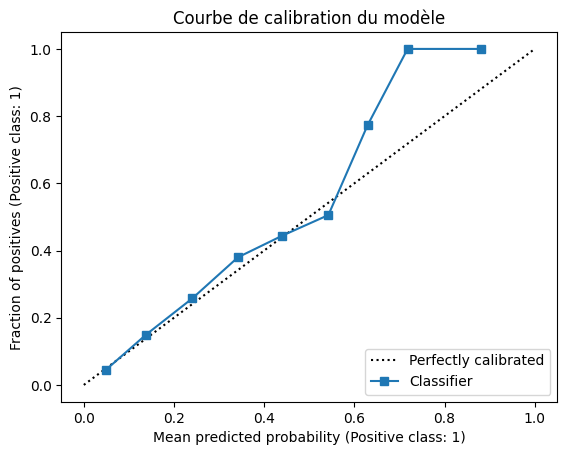

In [33]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

y_prob = pipe_gbc_all_final.predict_proba(X_test)[:, 1]

disp = CalibrationDisplay.from_predictions(
    y_test, y_prob,
    n_bins=10
)

plt.title("Courbe de calibration du modèle")
plt.show()
